# 02 - Exploratory Data Analysis

This notebook explores the two cleaned datasets produced in `01_Data_Ingestion_And_Cleaning.ipynb`.  
The goal is to understand the distributions, identify patterns by route and nationality, and get a feel for where anomalies might concentrate — before running any detection model.

**Datasets used:**
- `viaggiatori_clean.csv` — one row per traveler check, with demographics and control outcome
- `allarmi_clean.csv` — aggregated alarm counts by route, date and occurrence type

**Structure:**
1. Setup & load
2. TIPOLOGIA_VIAGGIATORE — descriptive stats, distributions, alarm rates
3. ALLARMI — volume and alarm breakdown by route and month
4. Alarm rate by nationality and zone

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('project_anomaly_detection')

v = pd.read_csv(DATA_DIR / 'viaggiatori_clean.csv')
a = pd.read_csv(DATA_DIR / 'allarmi_clean.csv', parse_dates=['DATA_PARTENZA'])

print('viaggiatori:', v.shape)
print('allarmi:    ', a.shape)

## 1. TIPOLOGIA_VIAGGIATORE

### 1.1 Descriptive statistics

In [78]:
num_cols = ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']

desc = v[num_cols].describe().T
desc['skewness'] = v[num_cols].skew()
desc['kurtosis'] = v[num_cols].kurt()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
ENTRATI,5007.0,42.49,248.40,0.0,1.0,3.0,76.0,10000.0,38.62,1546.22
INVESTIGATI,5008.0,41.56,227.37,0.0,1.0,2.0,75.0,9999.0,37.71,1558.52
ALLARMATI,5017.0,7.47,71.79,0.0,0.0,1.0,10.0,5000.0,67.12,4666.55


### 1.2 Distributions and boxplots

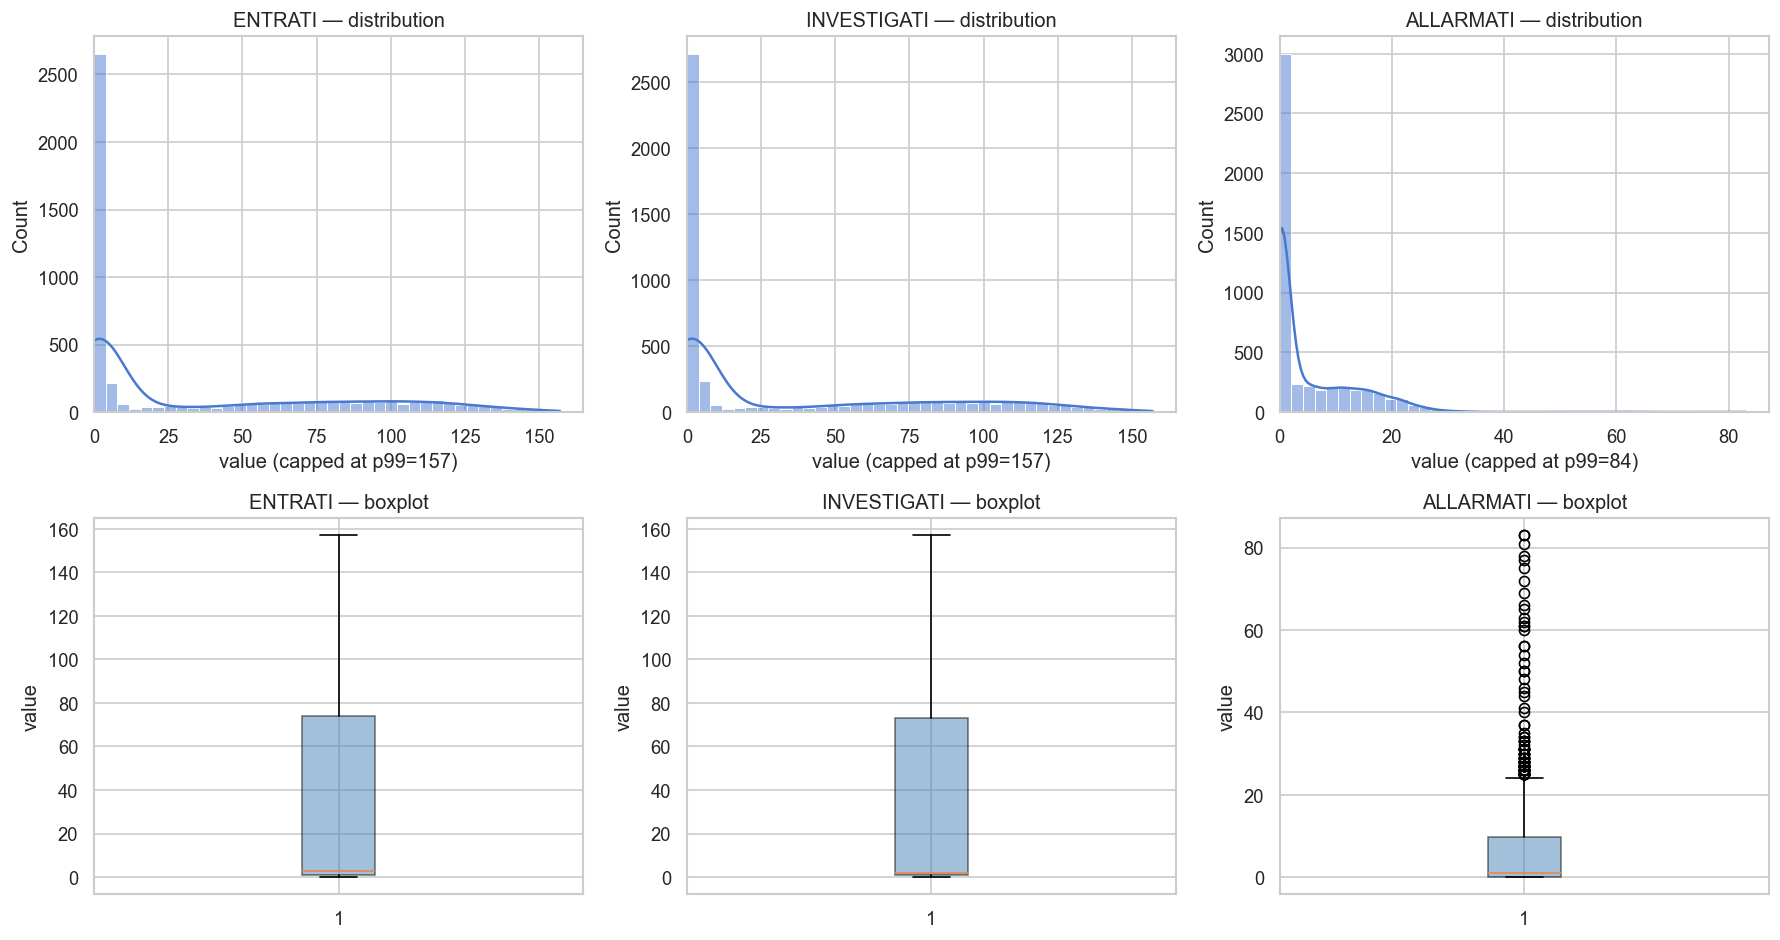

In [79]:
# histogram + kde + boxplot for each numeric column
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    data = v[col].dropna()
    cap  = data.quantile(0.99)
    data_capped = data[data <= cap]

    # histogram + kde
    sns.histplot(data_capped, bins=40, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'{col} — distribution')
    axes[0, i].set_xlabel(f'value (capped at p99={cap:.0f})')
    axes[0, i].set_xlim(left=0)

    # boxplot
    axes[1, i].boxplot(data_capped, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[1, i].set_title(f'{col} — boxplot')
    axes[1, i].set_ylabel('value')

plt.tight_layout()
plt.show()

### 1.3 Correlation heatmap

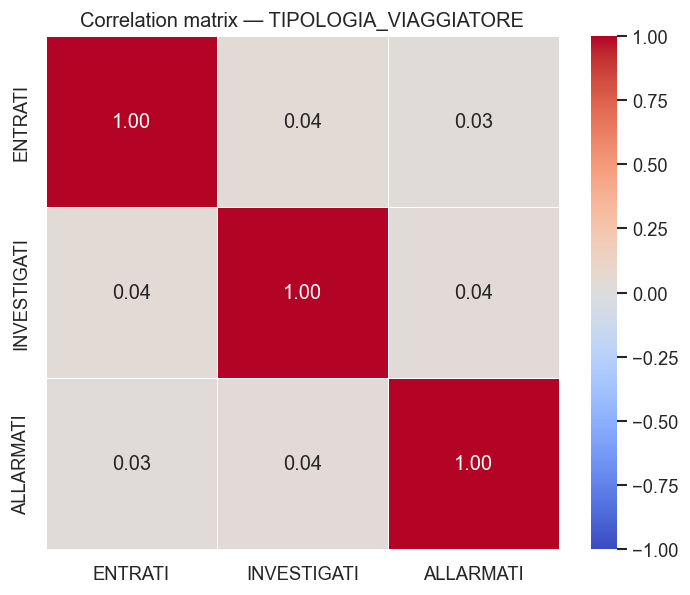

In [80]:
corr = v[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation matrix — TIPOLOGIA_VIAGGIATORE')
plt.tight_layout()
plt.show()

### 1.4 Frequency tables — categorical columns

In [81]:
cat_cols = ['NAZIONALITA', 'TIPO_DOCUMENTO', 'GENERE', 'FASCIA_ETA', 'ESITO_CONTROLLO']

for col in cat_cols:
    freq = v[col].value_counts(dropna=False).head(10).to_frame('count')
    freq['%'] = (freq['count'] / len(v) * 100).round(1)
    print(f'=== {col} ===')
    print(freq.to_string())
    print()

=== NAZIONALITA ===
             count     %
NAZIONALITA             
ALB           4281  84.0
AFG            386   7.6
NaN            321   6.3
AGO             50   1.0
AND             35   0.7
ARE             19   0.4
ABW              2   0.0
AIA              1   0.0

=== TIPO_DOCUMENTO ===
                       count     %
TIPO_DOCUMENTO                    
NaN                     1810  35.5
Visto                    867  17.0
Permesso di soggiorno    827  16.2
Passaporto               811  15.9
Carta d'identità         780  15.3

=== GENERE ===
        count     %
GENERE             
F        2226  43.7
M        2195  43.1
NaN       674  13.2

=== FASCIA_ETA ===
            count     %
FASCIA_ETA             
46-60         943  18.5
31-45         922  18.1
18-30         916  18.0
0-17          904  17.7
61+           884  17.4
NaN           526  10.3

=== ESITO_CONTROLLO ===
                 count     %
ESITO_CONTROLLO             
NaN               1289  25.3
SEGNALATO          80

### 1.5 Alarm rates by demographic variables

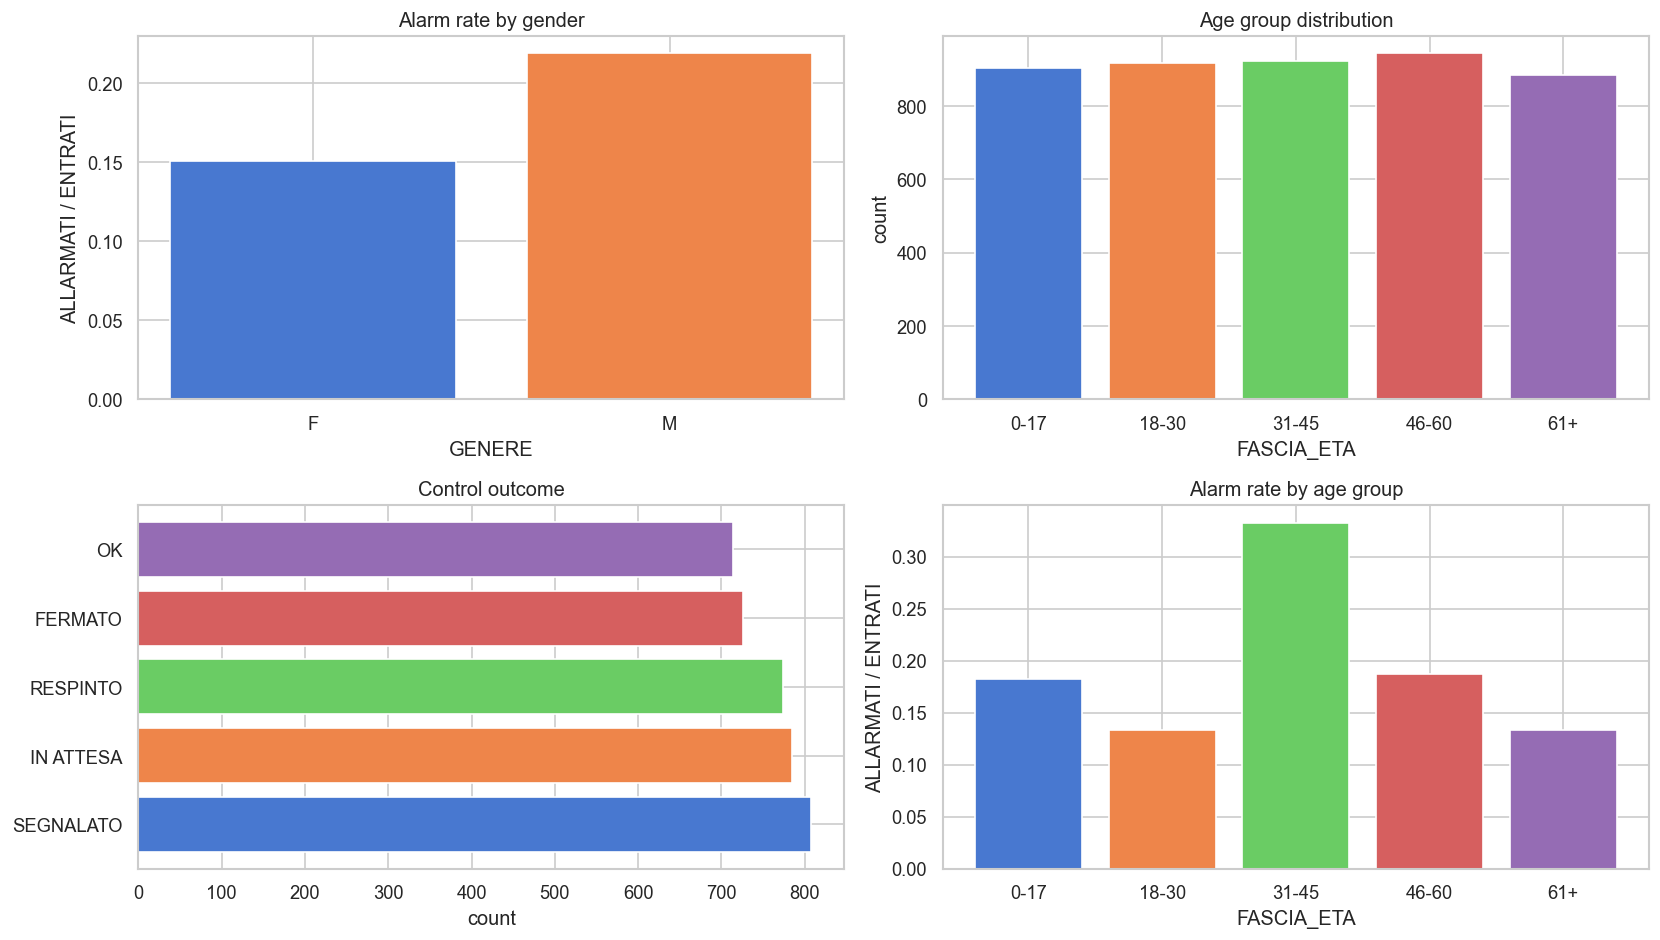

In [82]:
# distributions and alarm rates for key categorical columns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# alarm rate by gender
genere_stats = v.groupby('GENERE')[['ENTRATI', 'ALLARMATI']].sum()
genere_stats['alarm_rate'] = genere_stats['ALLARMATI'] / genere_stats['ENTRATI']
axes[0, 0].bar(genere_stats.index, genere_stats['alarm_rate'], color=sns.color_palette('muted'))
axes[0, 0].set_title('Alarm rate by gender')
axes[0, 0].set_xlabel('GENERE')
axes[0, 0].set_ylabel('ALLARMATI / ENTRATI')

# FASCIA_ETA — explicit order so it's always chronological
age_order = ['0-17', '18-30', '31-45', '46-60', '61+']
eta = v['FASCIA_ETA'].value_counts(dropna=True).reindex(age_order, fill_value=0)
axes[0, 1].bar(eta.index, eta.values, color=sns.color_palette('muted'))
axes[0, 1].set_title('Age group distribution')
axes[0, 1].set_xlabel('FASCIA_ETA')
axes[0, 1].set_ylabel('count')

# ESITO_CONTROLLO
esito = v['ESITO_CONTROLLO'].value_counts(dropna=True)
axes[1, 0].barh(esito.index.astype(str), esito.values, color=sns.color_palette('muted'))
axes[1, 0].set_title('Control outcome')
axes[1, 0].set_xlabel('count')

# alarm rate by age group
age_stats = v.groupby('FASCIA_ETA')[['ENTRATI', 'ALLARMATI']].sum()
age_stats = age_stats.reindex(age_order).dropna()
age_stats['alarm_rate'] = age_stats['ALLARMATI'] / age_stats['ENTRATI']
axes[1, 1].bar(age_stats.index, age_stats['alarm_rate'], color=sns.color_palette('muted'))
axes[1, 1].set_title('Alarm rate by age group')
axes[1, 1].set_xlabel('FASCIA_ETA')
axes[1, 1].set_ylabel('ALLARMATI / ENTRATI')

plt.tight_layout()
plt.show()

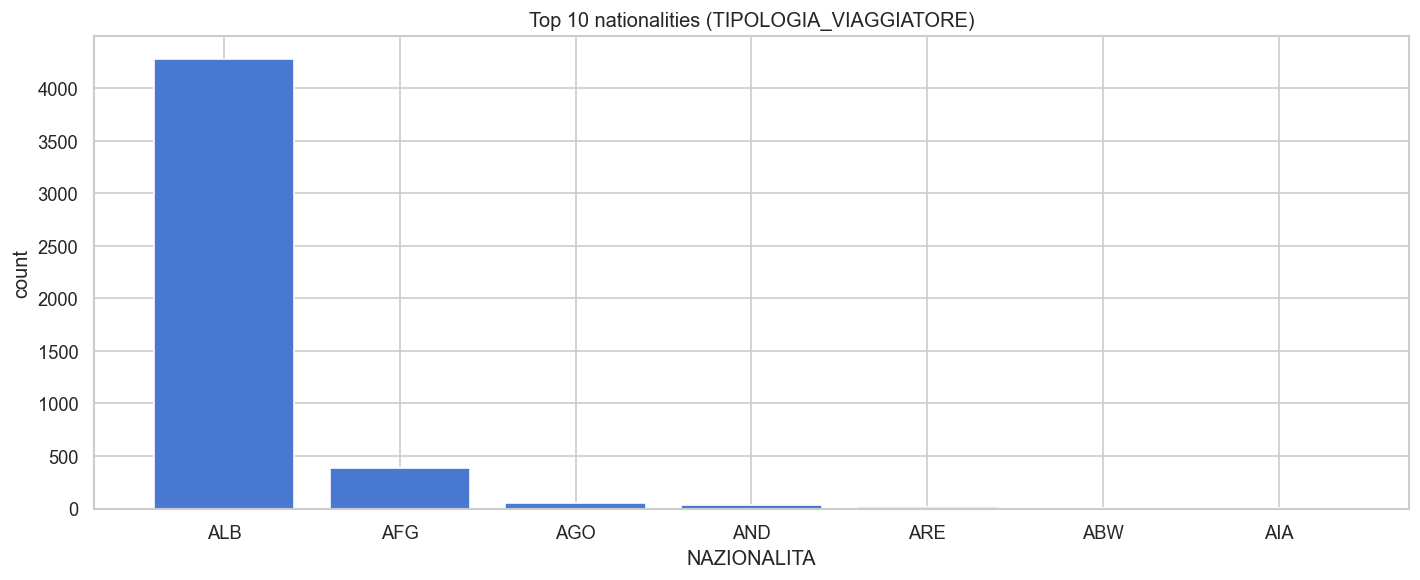

In [83]:
# top 10 nationalities
top_naz = v['NAZIONALITA'].value_counts(dropna=True).head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_naz.index, top_naz.values)
plt.title('Top 10 nationalities (TIPOLOGIA_VIAGGIATORE)')
plt.xlabel('NAZIONALITA')
plt.ylabel('count')
plt.tight_layout()
plt.show()

### 1.6 Top nationalities and document type

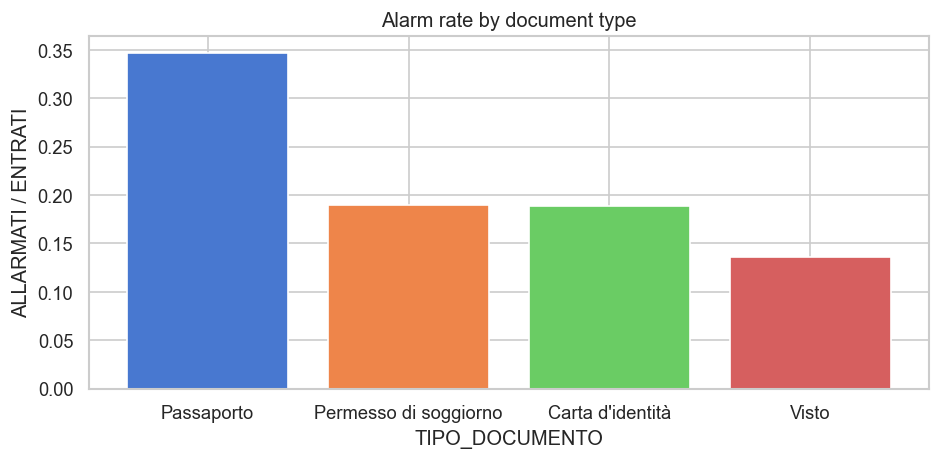

In [86]:
# alarm rate by document type
doc_stats = v.groupby('TIPO_DOCUMENTO')[['ENTRATI', 'ALLARMATI']].sum()
doc_stats['alarm_rate'] = doc_stats['ALLARMATI'] / doc_stats['ENTRATI']
doc_stats = doc_stats.sort_values('alarm_rate', ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(doc_stats.index, doc_stats['alarm_rate'], color=sns.color_palette('muted'))
plt.title('Alarm rate by document type')
plt.xlabel('TIPO_DOCUMENTO')
plt.ylabel('ALLARMATI / ENTRATI')
plt.tight_layout()
plt.show()

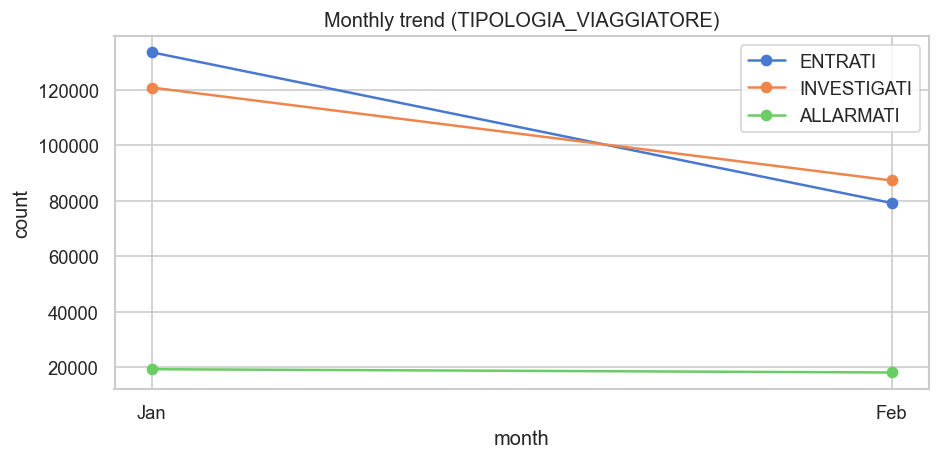

In [87]:
# monthly trend — exclude month 12 (data entry errors from rows with wrong year)
month_stats = v[v['MESE_PARTENZA'] != 12].groupby('MESE_PARTENZA')[['ENTRATI', 'INVESTIGATI', 'ALLARMATI']].sum()
month_labels = {1: 'Jan', 2: 'Feb'}
month_stats.index = month_stats.index.map(lambda x: month_labels.get(int(x), str(x)))

plt.figure(figsize=(8, 4))
for col in ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']:
    plt.plot(month_stats.index, month_stats[col], marker='o', label=col)
plt.title('Monthly trend (TIPOLOGIA_VIAGGIATORE)')
plt.xlabel('month')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

### 1.7 Monthly trend

## 2. ALLARMI

### 2.1 Descriptive statistics

In [88]:
desc_a = a[['TOT']].describe().T
desc_a['skewness'] = a[['TOT']].skew()
desc_a['kurtosis'] = a[['TOT']].kurt()
desc_a.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
TOT,4956.0,40.85,75.31,0.0,1.0,2.0,28.0,544.0,2.13,4.48


### 2.2 Distribution and boxplot — TOT

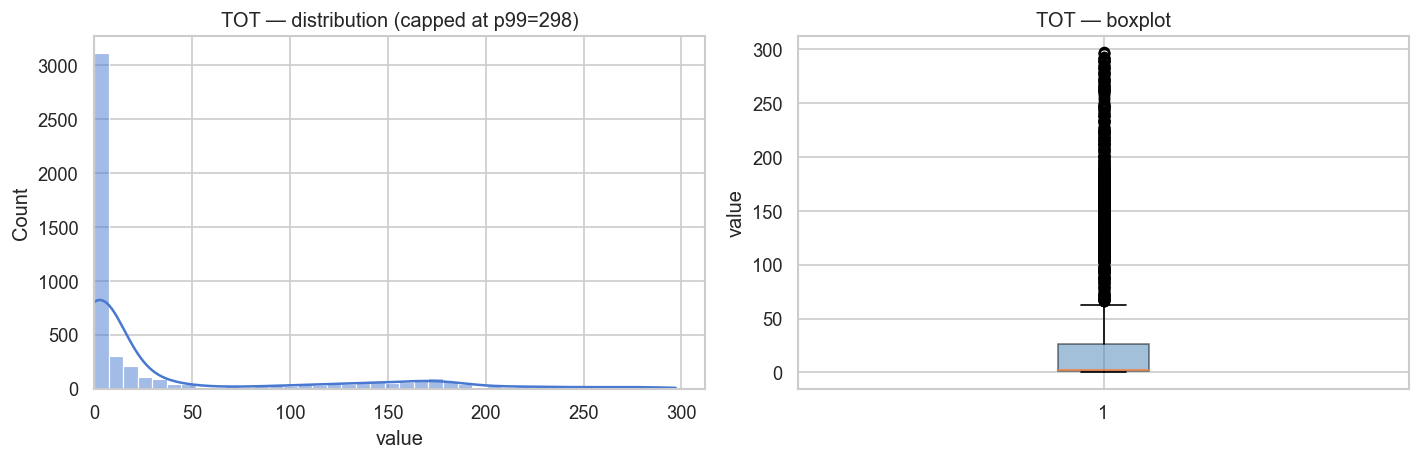

In [89]:
tot = a['TOT'].dropna()
cap_tot = tot.quantile(0.99)
tot_capped = tot[tot <= cap_tot]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(tot_capped, bins=40, kde=True, ax=axes[0])
axes[0].set_title(f'TOT — distribution (capped at p99={cap_tot:.0f})')
axes[0].set_xlabel('value')
axes[0].set_xlim(left=0)

axes[1].boxplot(tot_capped, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('TOT — boxplot')
axes[1].set_ylabel('value')

plt.tight_layout()
plt.show()

### 2.3 Frequency tables — categorical columns

In [90]:
cat_cols_a = ['OCCORRENZE', 'MOTIVO_ALLARME', 'ZONA', 'CODICE_PAESE_PART']

for col in cat_cols_a:
    freq = a[col].value_counts(dropna=False).head(10).to_frame('count')
    freq['%'] = (freq['count'] / len(a) * 100).round(1)
    print(f'=== {col} ===')
    print(freq.to_string())
    print()

=== OCCORRENZE ===
                                              count     %
OCCORRENZE                                               
Viaggiatori entrati nel Sistema                 626  12.3
Voli disponibili in ingresso al Sistema         588  11.6
Voli solo visualizzati, ma NON investigati      572  11.3
Voli investigati (SDI/NSIS - INTERPOL - TSC)    543  10.7
Viaggiatori investigati                         528  10.4
Allarmi generati da SDI/NSIS                    513  10.1
Voli con Allarmi                                507  10.0
Viaggiatori con Allarmi                         468   9.2
Nulla a procedere SDI                           251   4.9
Allarmi Chiusi                                  245   4.8

=== MOTIVO_ALLARME ===
                count     %
MOTIVO_ALLARME             
NaN              1160  22.8
SDI               817  16.1
TSC               816  16.1
Manuale           781  15.4
NSIS              763  15.0
INTERPOL          743  14.6

=== ZONA ===
      count     %
ZONA 

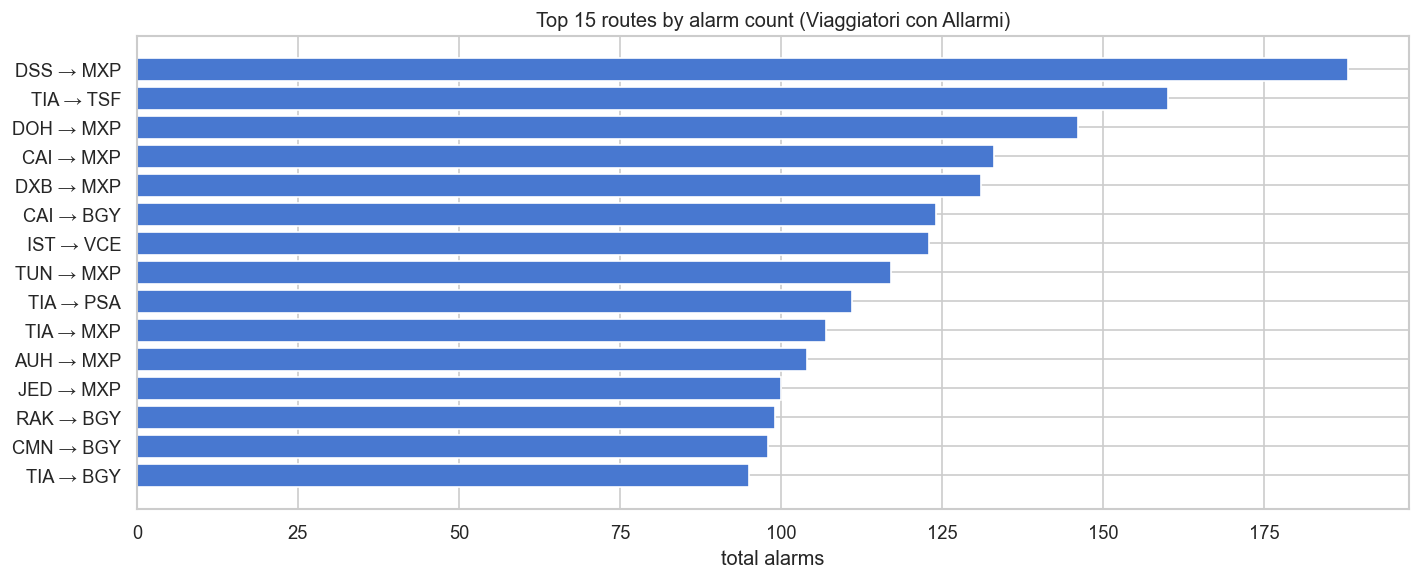

In [92]:
# top 15 routes by total alarms
route_alarms = a[a['OCCORRENZE'] == 'Viaggiatori con Allarmi'].groupby(
    ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO'])['TOT'].sum().sort_values(ascending=False).head(15)

route_alarms.index = [f"{p} → {ar}" for p, ar in route_alarms.index]

plt.figure(figsize=(12, 5))
plt.barh(route_alarms.index[::-1], route_alarms.values[::-1])
plt.title('Top 15 routes by alarm count (Viaggiatori con Allarmi)')
plt.xlabel('total alarms')
plt.tight_layout()
plt.show()

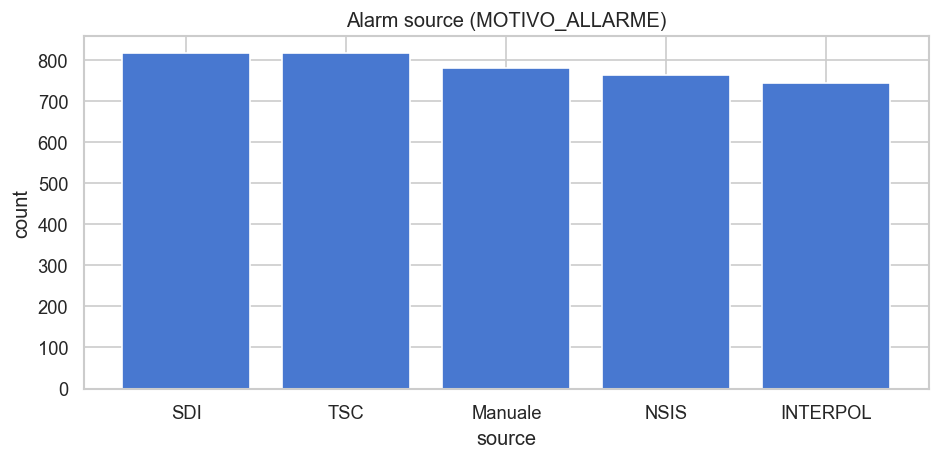

In [93]:
# alarm breakdown by MOTIVO_ALLARME
motivo = a['MOTIVO_ALLARME'].value_counts(dropna=True)

plt.figure(figsize=(8, 4))
plt.bar(motivo.index, motivo.values)
plt.title('Alarm source (MOTIVO_ALLARME)')
plt.xlabel('source')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## 3. Alarm rate by nationality and zone

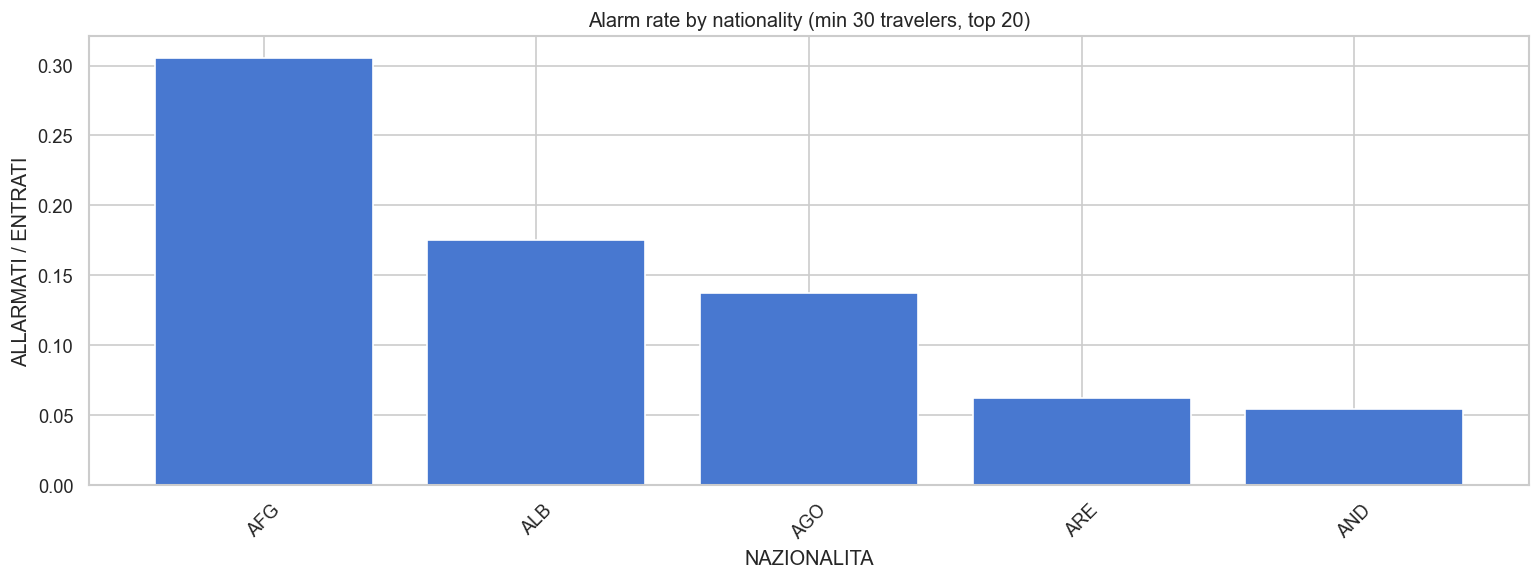

In [94]:
# alarm rate per nationality: ALLARMATI / ENTRATI
# only where we have enough records to be meaningful (min 30 travelers)
nat_stats = v.groupby('NAZIONALITA').agg(
    entrati=('ENTRATI', 'sum'),
    allarmati=('ALLARMATI', 'sum')
).dropna()

nat_stats = nat_stats[nat_stats['entrati'] >= 30].copy()
nat_stats['alarm_rate'] = nat_stats['allarmati'] / nat_stats['entrati']
nat_stats = nat_stats.sort_values('alarm_rate', ascending=False).head(20)

plt.figure(figsize=(13, 5))
plt.bar(nat_stats.index, nat_stats['alarm_rate'])
plt.title('Alarm rate by nationality (min 30 travelers, top 20)')
plt.xlabel('NAZIONALITA')
plt.ylabel('ALLARMATI / ENTRATI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# alarm rate and volume by ZONA — exclude invalid codes (-1, 0, 99, 10)
valid_zones = [1, 2, 4, 5, 6, 7, 8, 9]
zona_df = v[v['ZONA'].isin(valid_zones)].groupby('ZONA')[['ENTRATI', 'ALLARMATI']].sum()
zona_df['alarm_rate'] = zona_df['ALLARMATI'] / zona_df['ENTRATI']
zona_df = zona_df.sort_values('alarm_rate', ascending=False)
zona_df.index = zona_df.index.astype(int).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(zona_df.index, zona_df['alarm_rate'], color=sns.color_palette('muted'))
axes[0].set_title('Alarm rate by ZONA')
axes[0].set_xlabel('ZONA')
axes[0].set_ylabel('ALLARMATI / ENTRATI')

axes[1].bar(zona_df.index, zona_df['ENTRATI'], color=sns.color_palette('muted'))
axes[1].set_title('Traveler volume by ZONA')
axes[1].set_xlabel('ZONA')
axes[1].set_ylabel('ENTRATI')

plt.tight_layout()
plt.show()

print(zona_df[['ENTRATI', 'ALLARMATI', 'alarm_rate']].round(3).to_string())